In [329]:
import jax.numpy as jnp
from tensorflow_probability.substrates import jax as tfp

import numpy as np
from numpy import linalg
from matplotlib import pyplot as plt

## Define log-pds

In [700]:
tfd = tfp.distributions

### Create a mixture of three Bivariate Gaussians:

gm = tfd.MixtureSameFamily(
  mixture_distribution=tfd.Categorical(
      probs=jnp.array([0.2, 0.2, 0.2, 0.2])),
  components_distribution=tfd.MultivariateNormalDiag(
      loc=jnp.array([[-1., 1], 
           [1, -1],
           [-1, -1],
           [1, 1]]),  
      scale_identity_multiplier=jnp.array([.2, .2, .2, .2])))

(-2.0, 2.0)

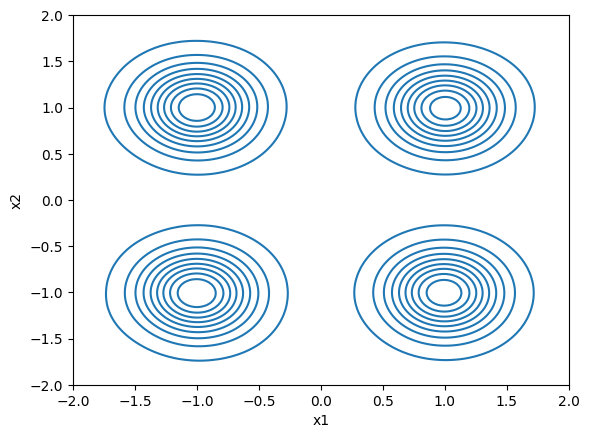

In [701]:
samples_truth = gm.sample(10000, seed=rng_key)

samples['x1'] = samples_truth[:, 0]
samples['x2'] = samples_truth[:, 1]

sns.kdeplot(data=samples, x='x1', y='x2')
plt.xlim(-2, 2)
plt.ylim(-2, 2)

In [331]:
@jax.jit
def loglike(x):
    return gm.log_prob(x)
    
def log_prior(x):
    if -2.0 < x[0] < 2.0 and -2.0 < x[0] < 2.0:
        return 0.0
    return -np.inf

def log_probability(x):
    lp = log_prior(x)
    if not np.isfinite(lp):
        return -np.inf
    return np.array(lp + loglike(x))

## `emcee`

In [332]:
import emcee

pos = jnp.array(np.array([0.5, 0.5]) + 1e-3 * np.random.randn(16, 2))
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability
)

sampler.run_mcmc(pos, 10000, progress=True);

100%|██████| 10000/10000 [00:02<00:00, 4270.77it/s]


(-2.0, 2.0)

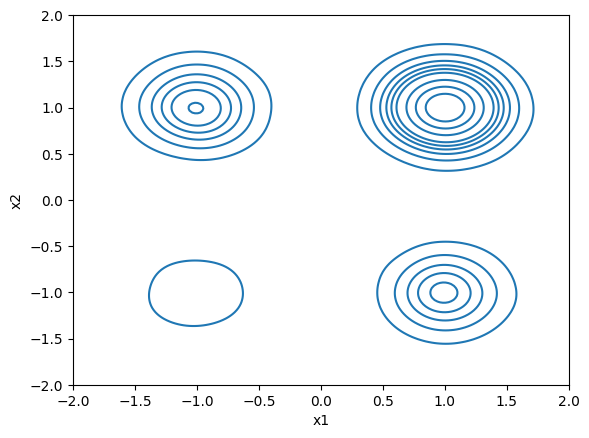

In [333]:
flat_samples = sampler.get_chain(discard=100, thin=5, flat=True)

samples = {}
samples['x1'] = flat_samples[:, 0]
samples['x2'] = flat_samples[:, 1]

sns.kdeplot(data=samples, x='x1', y='x2')
plt.xlim(-2, 2)
plt.ylim(-2, 2)

## `NumPyro`

In [336]:
import jax

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, HMC, HMCECS, NUTS, Predictive

In [337]:
def model():
    x1 = numpyro.sample("x1", dist.Uniform(-2., 2.))
    x2 = numpyro.sample("x2", dist.Uniform(-2., 2.))
    return numpyro.factor('log-likelihood', loglike(jnp.array([x1, x2])))

In [338]:
kernel = NUTS(model)
num_samples = 10000
num_chains = 8
mcmc = MCMC(kernel, num_warmup=1000, num_samples=num_samples, num_chains=num_chains, chain_method='vectorized')
rng_key = jax.random.PRNGKey(0)
mcmc.run(rng_key)

sample: 100%|█| 11000/11000 [00:08<00:00, 1348.72it


(-2.0, 2.0)

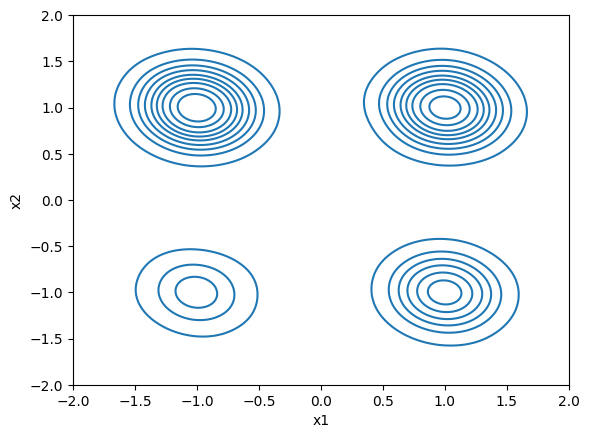

In [326]:
import seaborn as sns
sns.kdeplot(data=mcmc.get_samples(), x='x1', y='x2')
plt.xlim(-2, 2)
plt.ylim(-2, 2)

In [670]:
from numpyro.infer import SVI, Predictive, Trace_ELBO, autoguide
from numpyro import optim
import optax

In [671]:
guide = autoguide.AutoBNAFNormal(model, num_flows=4, hidden_factors=[64, 64])

In [672]:
lr=1e-3
optimizer = optim.optax_to_numpyro(optax.chain(optax.clip(1.), optax.adamw(lr)))

svi = SVI(model, guide, optimizer, Trace_ELBO(num_particles=2))
rng_key = jax.random.PRNGKey(0)
svi_results = svi.run(rng_key, 20000)

100%|█| 20000/20000 [00:50<00:00, 393.72it/s, init 


In [673]:
posterior = guide.sample_posterior(rng_key=rng_key, params=svi_results.params, sample_shape=(10000,))

(-2.0, 2.0)

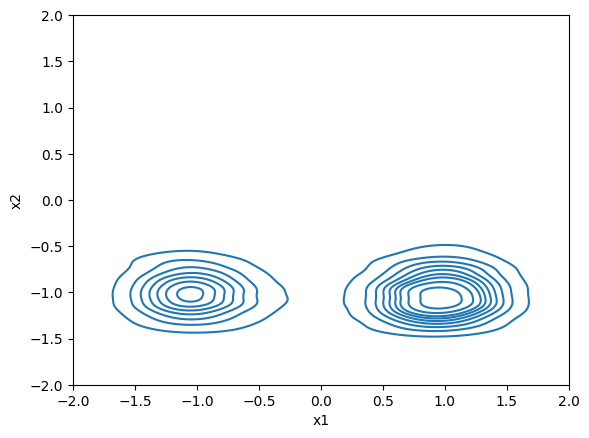

In [674]:
import seaborn as sns
sns.kdeplot(data=posterior, x='x1', y='x2')
plt.xlim(-2, 2)
plt.ylim(-2, 2)

In [382]:
from numpyro.infer.reparam import NeuTraReparam

In [383]:
neutra = NeuTraReparam(guide, svi_results.params)
neutra_model = neutra.reparam(model)

In [414]:
kernel = NUTS(neutra_model)
num_samples = 10000
num_chains = 1
mcmc = MCMC(kernel, num_warmup=1000, num_samples=num_samples, num_chains=num_chains, chain_method='vectorized')
rng_key = jax.random.PRNGKey(0)
mcmc.run(rng_key)

(-2.0, 2.0)

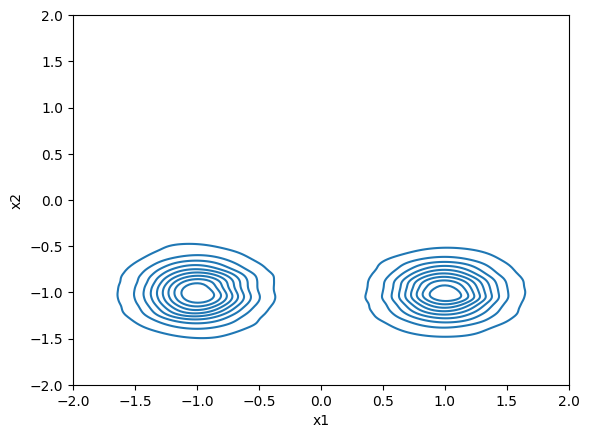

In [385]:
neutra_samples = mcmc.get_samples(group_by_chain=True)["auto_shared_latent"]
samples = neutra.transform_sample(neutra_samples)

samples['x1'] = samples['x1'].flatten()
samples['x2'] = samples['x2'].flatten()

sns.kdeplot(data=samples, x='x1', y='x2')
plt.xlim(-2, 2)
plt.ylim(-2, 2)

In [709]:
from numpyro.contrib.tfp.mcmc import ReplicaExchangeMC

In [710]:
# Geometric decay is a good rule of thumb.
inverse_temperatures = 0.5 ** jnp.arange(4.)

# If everything was Normal, step_size should be ~ sqrt(temperature).
step_size = 5e-2 / jnp.sqrt(inverse_temperatures)[..., None]

def make_kernel_fn(target_log_prob_fn):
    return tfp.mcmc.HamiltonianMonteCarlo(
      target_log_prob_fn=target_log_prob_fn,
      step_size=step_size, num_leapfrog_steps=5)

In [711]:
kernel = ReplicaExchangeMC(model, inverse_temperatures=inverse_temperatures, make_kernel_fn=make_kernel_fn)
num_samples = 10000
num_chains = 1
mcmc = MCMC(kernel, num_warmup=1000, num_samples=num_samples, num_chains=num_chains, chain_method='vectorized')
rng_key = jax.random.PRNGKey(0)
mcmc.run(rng_key)

  0%|                    | 0/11000 [00:00<?, ?it/s]/opt/homebrew/Caskroom/miniforge/base/envs/torch-mps/lib/python3.9/site-packages/tensorflow_probability/python/internal/backend/jax/ops.py:282: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return arr.astype(dtype)
/opt/homebrew/Caskroom/miniforge/base/envs/torch-mps/lib/python3.9/site-packages/tensorflow_probability/python/internal/backend/jax/ops.py:389: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return x.astyp

/opt/homebrew/Caskroom/miniforge/base/envs/torch-mps/lib/python3.9/site-packages/seaborn/distributions.py:1185: UserWarning: The following kwargs were not used by contour: 'ls'
  cset = contour_func(


(-2.0, 2.0)

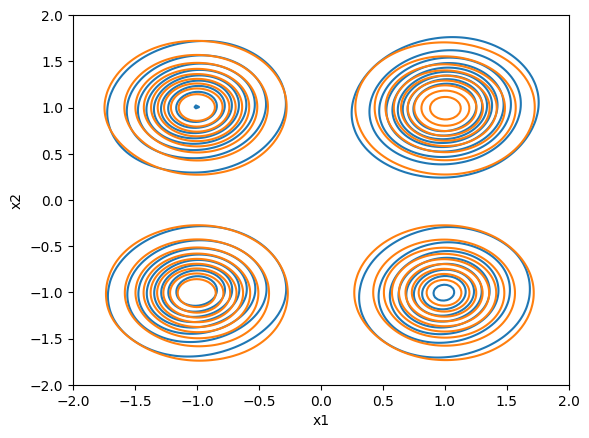

In [712]:
import seaborn as sns
sns.kdeplot(data=mcmc.get_samples(), x='x1', y='x2')

samples_truth = gm.sample(10000, seed=rng_key)

samples['x1'] = samples_truth[:, 0]
samples['x2'] = samples_truth[:, 1]
sns.kdeplot(data=samples, x='x1', y='x2', ls='--')

plt.xlim(-2, 2)
plt.ylim(-2, 2)

In [713]:
# Geometric decay is a good rule of thumb.
inverse_temperatures = 0.5 ** jnp.arange(4.)

# If everything was Normal, step_size should be ~ sqrt(temperature).
step_size = 5e-2 / jnp.sqrt(inverse_temperatures)[..., None]

def make_kernel_fn(target_log_prob_fn):
    
    hmc = tfp.mcmc.HamiltonianMonteCarlo(
    target_log_prob_fn=target_log_prob_fn,
    step_size=step_size, num_leapfrog_steps=3)

    adapted_kernel = tfp.mcmc.SimpleStepSizeAdaptation(
    inner_kernel=hmc,
    num_adaptation_steps=600)

    return adapted_kernel

In [714]:
kernel = ReplicaExchangeMC(neutra_model, inverse_temperatures=inverse_temperatures, make_kernel_fn=make_kernel_fn)
num_samples = 10000
num_chains = 1
mcmc = MCMC(kernel, num_warmup=1000, num_samples=num_samples, num_chains=num_chains, chain_method='vectorized')
rng_key = jax.random.PRNGKey(0)
mcmc.run(rng_key)

  0%|                    | 0/11000 [00:00<?, ?it/s]/opt/homebrew/Caskroom/miniforge/base/envs/torch-mps/lib/python3.9/site-packages/tensorflow_probability/python/internal/backend/jax/ops.py:282: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return arr.astype(dtype)
/opt/homebrew/Caskroom/miniforge/base/envs/torch-mps/lib/python3.9/site-packages/tensorflow_probability/python/internal/backend/jax/ops.py:389: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return x.astyp

/opt/homebrew/Caskroom/miniforge/base/envs/torch-mps/lib/python3.9/site-packages/seaborn/distributions.py:1185: UserWarning: The following kwargs were not used by contour: 'ls'
  cset = contour_func(


(-2.0, 2.0)

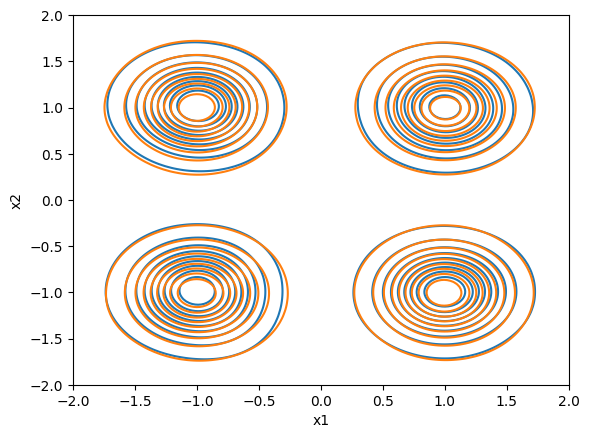

In [715]:
neutra_samples = mcmc.get_samples(group_by_chain=True)["auto_shared_latent"]
samples = neutra.transform_sample(neutra_samples)

samples['x1'] = samples['x1'].flatten()
samples['x2'] = samples['x2'].flatten()
sns.kdeplot(data=samples, x='x1', y='x2')

samples_truth = gm.sample(10000, seed=rng_key)

samples['x1'] = samples_truth[:, 0]
samples['x2'] = samples_truth[:, 1]
sns.kdeplot(data=samples, x='x1', y='x2', ls='--')

plt.xlim(-2, 2)
plt.ylim(-2, 2)